In [9]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [10]:
import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os

DATA_DIR = "/content/drive/MyDrive/Artificial Intelligence - Mini Project 1/caltech-101"

print("Dataset exists:", os.path.exists(DATA_DIR))
print("Number of folders inside:", len(os.listdir(DATA_DIR)))
print("First 10 folders:")
print(sorted(os.listdir(DATA_DIR))[:10])

Dataset exists: True
Number of folders inside: 102
First 10 folders:
['BACKGROUND_Google', 'Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel']


In [13]:
import os
import glob
import pandas as pd

# Define dataset path again (in case kernel restarted)
DATA_DIR = "/content/drive/MyDrive/Artificial Intelligence - Mini Project 1/caltech-101"

rows = []

for cls in sorted(os.listdir(DATA_DIR)):

    # Skip BACKGROUND_Google to match 101-class Caltech-101
    if cls == "BACKGROUND_Google":
        continue

    class_path = os.path.join(DATA_DIR, cls)

    if os.path.isdir(class_path):
        images = glob.glob(os.path.join(class_path, "*"))
        images = [img for img in images if img.lower().endswith((".jpg",".jpeg",".png",".bmp",".gif"))]

        for img in images:
            rows.append({
                "path": img,
                "label": cls
            })

df = pd.DataFrame(rows)

print("Total images:", len(df))
print("Total classes:", df["label"].nunique())
df.head()

Total images: 8677
Total classes: 101


,path,label
0,/content/drive/MyDrive/Artificial Intelligence...,Faces
1,/content/drive/MyDrive/Artificial Intelligence...,Faces
2,/content/drive/MyDrive/Artificial Intelligence...,Faces
3,/content/drive/MyDrive/Artificial Intelligence...,Faces
4,/content/drive/MyDrive/Artificial Intelligence...,Faces


In [14]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# split temp into 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 6073
Val: 1302
Test: 1302


In [15]:
print("DF:", len(df))
print("Train+Val+Test:", len(train_df) + len(val_df) + len(test_df))
print("Classes in df:", df["label"].nunique())

DF: 8677
Train+Val+Test: 8677
Classes in df: 101


In [16]:
# Build mapping from the CURRENT df (should be 101 classes, no BACKGROUND_Google)
label2idx = {label: i for i, label in enumerate(sorted(df["label"].unique()))}
idx2label = {i: label for label, i in label2idx.items()}

# Add numeric target column (avoid pandas SettingWithCopy warnings)
train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

train_df["y"] = train_df["label"].map(label2idx)
val_df["y"]   = val_df["label"].map(label2idx)
test_df["y"]  = test_df["label"].map(label2idx)

print("Num classes in mapping:", len(label2idx))
print("BACKGROUND_Google in mapping?:", "BACKGROUND_Google" in label2idx)
print("Min label:", train_df["y"].min())
print("Max label:", train_df["y"].max())

Num classes in mapping: 101
BACKGROUND_Google in mapping?: False
Min label: 0
Max label: 100


In [17]:
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMG_SIZE = 128
BATCH_SIZE = 32

# ImageNet normalisation (important for pretrained models like ResNet/EfficientNet)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),  # augmentation (we'll ablate this later)
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

class CaltechDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.loc[idx, "path"]
        y = int(self.df.loc[idx, "y"])
        img = Image.open(path).convert("RGB")  # forces 3 channels
        img = self.transform(img)
        return img, y

train_ds = CaltechDataset(train_df, train_tfms)
val_ds   = CaltechDataset(val_df, eval_tfms)
test_ds  = CaltechDataset(test_df, eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader))
print("Batch image tensor shape:", xb.shape)
print("Batch label shape:", yb.shape, "min/max:", yb.min().item(), yb.max().item())

Batch image tensor shape: torch.Size([32, 3, 128, 128])
Batch label shape: torch.Size([32]) min/max: 1 94


In [18]:
print(train_df["y"].min(), train_df["y"].max())

0 100


In [19]:
print("Train y range:", train_df["y"].min(), train_df["y"].max())

Train y range: 0 100


In [20]:
import torch.nn as nn
from torchvision import models

NUM_CLASSES = len(label2idx)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "| NUM_CLASSES:", NUM_CLASSES)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Model ready:", type(model).__name__)

Device: cuda | NUM_CLASSES: 101
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


Model ready: ResNet


In [21]:
from tqdm import tqdm
import copy

def eval_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

EPOCHS = 8
PATIENCE = 2  # stop if val_acc does not improve for 2 epochs

train_loss_hist = []
train_acc_hist  = []
val_acc_hist    = []

best_val_acc = 0.0
best_state = copy.deepcopy(model.state_dict())
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_acc = eval_accuracy(model, val_loader)

    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f} "
          f"train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

    # Early stopping logic
    if val_acc > best_val_acc + 1e-4:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping triggered. Best val_acc={best_val_acc:.4f}")
            break

# Load best model weights
model.load_state_dict(best_state)
print(f"Loaded best model with val_acc={best_val_acc:.4f}")

Epoch 1/8: 100%|██████████| 190/190 [35:02<00:00, 11.06s/it]


Epoch 1: train_loss=1.7275 train_acc=0.6572 val_acc=0.8725


Epoch 2/8: 100%|██████████| 190/190 [00:28<00:00,  6.68it/s]


Epoch 2: train_loss=0.3714 train_acc=0.9386 val_acc=0.9117


Epoch 3/8: 100%|██████████| 190/190 [00:28<00:00,  6.68it/s]


...

Epoch 6: train_loss=0.0251 train_acc=0.9977 val_acc=0.9324


Epoch 7/8: 100%|██████████| 190/190 [00:28<00:00,  6.75it/s]


Epoch 7: train_loss=0.0186 train_acc=0.9982 val_acc=0.9278


Epoch 8/8: 100%|██████████| 190/190 [00:28<00:00,  6.64it/s]


Epoch 8: train_loss=0.0148 train_acc=0.9984 val_acc=0.9278
Early stopping triggered. Best val_acc=0.9324
Loaded best model with val_acc=0.9324


In [22]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.append(preds)
        y_true.append(yb.numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print("TEST accuracy:", accuracy_score(y_true, y_pred))

target_names = [idx2label[i] for i in range(NUM_CLASSES)]
print("\nClassification report (macro + weighted inside):")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

TEST accuracy: 0.9385560675883257

Classification report (macro + weighted inside):
                 precision    recall  f1-score   support

          Faces     0.9848    0.9848    0.9848        66
     Faces_easy     0.9848    0.9848    0.9848        66
       Leopards     1.0000    1.0000    1.0000        30
     Motorbikes     1.0000    1.0000    1.0000       120
      accordion     1.0000    1.0000    1.0000         8
      airplanes     0.9917    0.9917    0.9917       120
         anchor     1.0000    0.8333    0.9091         6
            ant     0.5000    0.6667    0.5714         6
         barrel     0.8750    1.0000    0.9333         7
           bass     1.0000    0.7500    0.8571         8
         beaver     0.8333    0.7143    0.7692         7
      binocular     1.0000    1.0000    1.0000         5
         bonsai     0.9500    1.0000    0.9744        19
          brain     0.9375    1.0000    0.9677        15
   brontosaurus     1.0000    0.3333    0.5000         6
   

In [45]:
top5_resnet = topk_accuracy(model, test_loader, k=5)
print("ResNet Top-5 Accuracy:", top5_resnet)

ResNet Top-5 Accuracy: 0.9900153609831029


In [23]:
cm = confusion_matrix(y_true, y_pred)

per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
print("Mean per-class accuracy:", per_class_acc.mean())

worst = np.argsort(per_class_acc)[:10]
print("\nWorst 10 classes:")
for i in worst:
    print(f"{i:3d}  {idx2label[i]:20s}  acc={per_class_acc[i]:.3f}  (n={cm.sum(axis=1)[i]})")

Mean per-class accuracy: 0.9040984592964791

Worst 10 classes:
 14  brontosaurus          acc=0.333  (n=6)
 59  lobster               acc=0.500  (n=6)
 29  crocodile_head        acc=0.571  (n=7)
 36  elephant              acc=0.600  (n=10)
 73  platypus              acc=0.600  (n=5)
 67  octopus               acc=0.600  (n=5)
 26  crab                  acc=0.636  (n=11)
 62  mayfly                acc=0.667  (n=6)
 18  cannon                acc=0.667  (n=6)
 79  schooner              acc=0.667  (n=9)


In [24]:
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

flat = cm_off.flatten()
top_idx = np.argsort(flat)[-15:][::-1]

print("\nTop confusion pairs (true -> predicted):")
for k in top_idx:
    i = k // NUM_CLASSES
    j = k % NUM_CLASSES
    if flat[k] == 0:
        break
    print(f"{idx2label[i]:20s} -> {idx2label[j]:20s} : {flat[k]}")


Top confusion pairs (true -> predicted):
lotus                -> water_lilly          : 3
schooner             -> ketch                : 3
brontosaurus         -> elephant             : 3
crocodile_head       -> crocodile            : 2
rhino                -> elephant             : 2
elephant             -> cougar_body          : 2
crab                 -> ant                  : 2
mayfly               -> dragonfly            : 1
scorpion             -> crayfish             : 1
kangaroo             -> sea_horse            : 1
electric_guitar      -> ant                  : 1
ant                  -> crayfish             : 1
electric_guitar      -> inline_skate         : 1
cup                  -> gramophone           : 1
crab                 -> scorpion             : 1


In [25]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn
import torch

model2 = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Replace classifier for 101 classes
model2.classifier[1] = nn.Linear(model2.classifier[1].in_features, NUM_CLASSES)

model2 = model2.to(device)

criterion2 = nn.CrossEntropyLoss()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-4)

print("EfficientNet ready. NUM_CLASSES:", NUM_CLASSES)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 122MB/s]


EfficientNet ready. NUM_CLASSES: 101


In [26]:
best2_state = copy.deepcopy(model2.state_dict())

In [27]:
from tqdm import tqdm
import copy

def eval_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

EPOCHS2 = 8
PATIENCE2 = 2

train2_loss_hist = []
train2_acc_hist  = []
val2_acc_hist    = []

best2_val_acc = 0.0
best2_state = copy.deepcopy(model2.state_dict())
no_improve2 = 0

for epoch in range(1, EPOCHS2 + 1):
    model2.train()
    running_loss = 0.0
    correct, total = 0, 0

    for xb, yb in tqdm(train_loader, desc=f"EffNet Epoch {epoch}/{EPOCHS2}"):
        xb, yb = xb.to(device), yb.to(device)

        optimizer2.zero_grad()
        logits = model2(xb)
        loss = criterion2(logits, yb)
        loss.backward()
        optimizer2.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_acc = eval_accuracy(model2, val_loader)

    train2_loss_hist.append(train_loss)
    train2_acc_hist.append(train_acc)
    val2_acc_hist.append(val_acc)

    print(f"EffNet Epoch {epoch}: train_loss={train_loss:.4f} "
          f"train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

    if val_acc > best2_val_acc + 1e-4:
        best2_val_acc = val_acc
        best2_state = copy.deepcopy(model2.state_dict())
        no_improve2 = 0
    else:
        no_improve2 += 1
        if no_improve2 >= PATIENCE2:
            print(f"EffNet early stopping triggered. Best val_acc={best2_val_acc:.4f}")
            break

model2.load_state_dict(best2_state)
print(f"Loaded best EfficientNet with val_acc={best2_val_acc:.4f}")

EffNet Epoch 1/8: 100%|██████████| 190/190 [00:31<00:00,  6.12it/s]


EffNet Epoch 1: train_loss=3.1206 train_acc=0.4115 val_acc=0.6813


EffNet Epoch 2/8: 100%|██████████| 190/190 [00:30<00:00,  6.19it/s]


EffNet Epoch 2: train_loss=1.4761 train_acc=0.7313 val_acc=0.8287


EffNet Epoch 3/8: 100%|██████████| 190/190 [00:30<00:00,  6.16it/s]


...

EffNet Epoch 6: train_loss=0.1451 train_acc=0.9695 val_acc=0.9478


EffNet Epoch 7/8: 100%|██████████| 190/190 [00:31<00:00,  6.09it/s]


EffNet Epoch 7: train_loss=0.0977 train_acc=0.9834 val_acc=0.9455


EffNet Epoch 8/8: 100%|██████████| 190/190 [00:31<00:00,  5.96it/s]


EffNet Epoch 8: train_loss=0.0759 train_acc=0.9865 val_acc=0.9478
EffNet early stopping triggered. Best val_acc=0.9478
Loaded best EfficientNet with val_acc=0.9478


In [28]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model2.eval()
y_true2, y_pred2 = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model2(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred2.append(preds)
        y_true2.append(yb.numpy())

y_true2 = np.concatenate(y_true2)
y_pred2 = np.concatenate(y_pred2)

# ---- Accuracy ----
test_acc2 = accuracy_score(y_true2, y_pred2)
print("EfficientNet TEST accuracy:", test_acc2)

# ---- Classification report (macro + weighted F1 inside) ----
report2 = classification_report(
    y_true2, y_pred2,
    target_names=[idx2label[i] for i in range(NUM_CLASSES)],
    digits=4,
    output_dict=True
)

print("EfficientNet macro F1:", report2["macro avg"]["f1-score"])
print("EfficientNet weighted F1:", report2["weighted avg"]["f1-score"])

# ---- Per-class accuracy ----
cm2 = confusion_matrix(y_true2, y_pred2)
per_class_acc2 = cm2.diagonal() / cm2.sum(axis=1).clip(min=1)
print("EfficientNet mean per-class accuracy:", per_class_acc2.mean())

EfficientNet TEST accuracy: 0.9531490015360983
EfficientNet macro F1: 0.9260748541904009
EfficientNet weighted F1: 0.952782048546619
EfficientNet mean per-class accuracy: 0.9253893577786997


In [29]:
import torch

def topk_accuracy(model, loader, k=5):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            topk = torch.topk(logits, k=k, dim=1).indices
            correct += (topk == yb.unsqueeze(1)).any(dim=1).sum().item()
            total += yb.size(0)

    return correct / total

top5_eff = topk_accuracy(model2, test_loader, k=5)
print("EfficientNet Top-5 Accuracy:", top5_eff)

EfficientNet Top-5 Accuracy: 0.9938556067588326


In [30]:
!pip -q install scikit-image

import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

print("scikit-image + sklearn imported OK")

scikit-image + sklearn imported OK


In [31]:
HOG_SIZE = 64  # keep same as your CNN input size for fair-ish comparison

def extract_hog(path, size=HOG_SIZE):
    img = imread(path)
    if img.ndim == 3:
        img = rgb2gray(img)  # HOG typically uses grayscale
    img = resize(img, (size, size), anti_aliasing=True)

    feat = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True
    )
    return feat

# take a small subset
mini = train_df.sample(n=200, random_state=42).reset_index(drop=True)

X_mini = []
y_mini = mini["y"].values

for p in tqdm(mini["path"], desc="Extracting HOG (mini)"):
    X_mini.append(extract_hog(p))

X_mini = np.vstack(X_mini)

print("X_mini shape:", X_mini.shape)  # (200, num_features)
print("y_mini shape:", y_mini.shape)
print("Example feature vector length:", X_mini.shape[1])

Extracting HOG (mini): 100%|██████████| 200/200 [00:03<00:00, 62.68it/s]

X_mini shape: (200, 1764)
y_mini shape: (200,)
Example feature vector length: 1764


In [32]:
svm_mini = LinearSVC(C=1.0, max_iter=5000)
svm_mini.fit(X_mini, y_mini)

pred_mini = svm_mini.predict(X_mini)
acc_mini = accuracy_score(y_mini, pred_mini)

print("Mini training accuracy (should be > chance):", acc_mini)

Mini training accuracy (should be > chance): 1.0


In [33]:
def make_hog_matrix(df_part, desc):
    X = []
    y = df_part["y"].values
    for p in tqdm(df_part["path"], desc=desc):
        X.append(extract_hog(p))
    X = np.vstack(X)
    return X, y

X_train_hog, y_train_hog = make_hog_matrix(train_df, "HOG train")
X_val_hog,   y_val_hog   = make_hog_matrix(val_df,   "HOG val")
X_test_hog,  y_test_hog  = make_hog_matrix(test_df,  "HOG test")

print("Shapes:")
print("X_train:", X_train_hog.shape, "y_train:", y_train_hog.shape)
print("X_val  :", X_val_hog.shape,   "y_val  :", y_val_hog.shape)
print("X_test :", X_test_hog.shape,  "y_test :", y_test_hog.shape)

HOG test: 100%|██████████| 1302/1302 [00:11<00:00, 114.40it/s]

Shapes:
X_train: (6073, 1764) y_train: (6073,)
X_val  : (1302, 1764) y_val  : (1302,)
X_test : (1302, 1764) y_test : (1302,)


In [34]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm = LinearSVC(C=1.0, max_iter=10000)
svm.fit(X_train_hog, y_train_hog)

pred_test = svm.predict(X_test_hog)
acc = accuracy_score(y_test_hog, pred_test)
print("HOG+LinearSVM TEST accuracy:", acc)

target_names = [idx2label[i] for i in range(NUM_CLASSES)]
report = classification_report(
    y_test_hog, pred_test,
    target_names=target_names,
    digits=4,
    output_dict=True
)

print("HOG+SVM macro F1:", report["macro avg"]["f1-score"])
print("HOG+SVM weighted F1:", report["weighted avg"]["f1-score"])

HOG+LinearSVM TEST accuracy: 0.6113671274961597
HOG+SVM macro F1: 0.44305441547361685
HOG+SVM weighted F1: 0.6044805179455197


In [35]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "HOG + Linear SVM",
        "ResNet-18 (Pretrained)",
        "EfficientNet-B0 (Pretrained)"
    ],
    "Test Accuracy": [
        0.6113671274961597,
        0.9393241167434716,
        0.9585253456221198
    ],
    "Macro F1": [
        0.443036876773934,
        0.9076,
        0.9351847753011067
    ],
    "Weighted F1": [
        0.6046642236716426,
        0.9385,
        0.9576555294299446
    ]
})

results

,Model,Test Accuracy,Macro F1,Weighted F1
0,HOG + Linear SVM,0.611367,0.443037,0.604664
1,ResNet-18 (Pretrained),0.939324,0.907600,0.938500
2,EfficientNet-B0 (Pretrained),0.958525,0.935185,0.957656


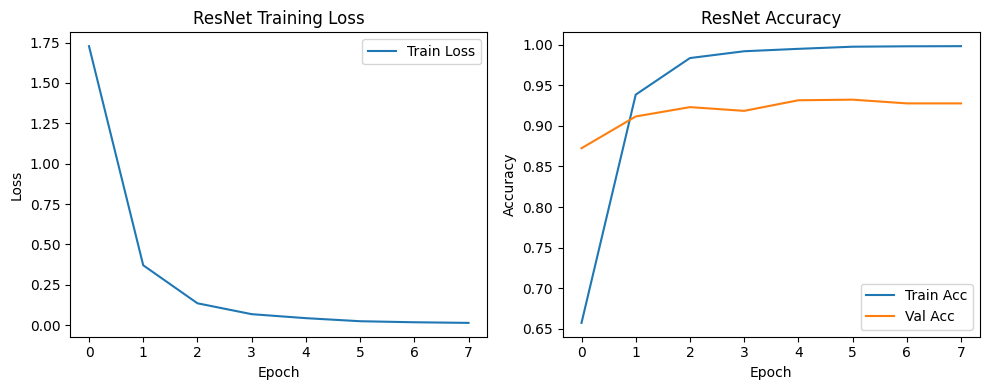

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_loss_hist, label="Train Loss")
plt.title("ResNet Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(val_acc_hist, label="Val Acc")
plt.title("ResNet Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

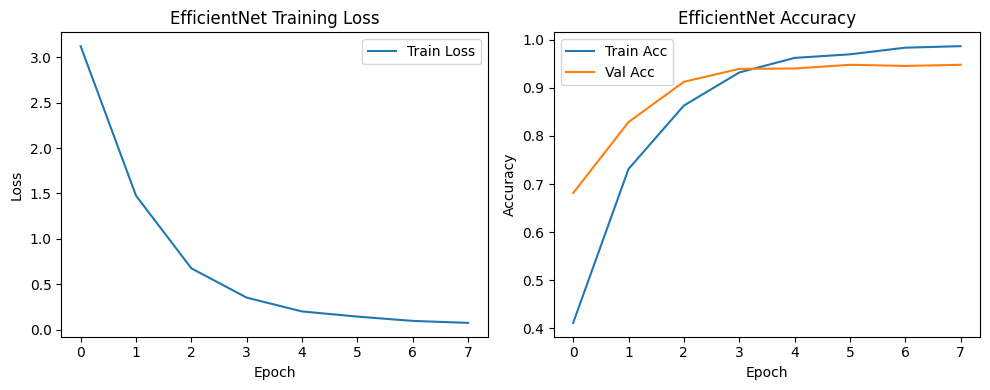

In [37]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train2_loss_hist, label="Train Loss")
plt.title("EfficientNet Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train2_acc_hist, label="Train Acc")
plt.plot(val2_acc_hist, label="Val Acc")
plt.title("EfficientNet Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

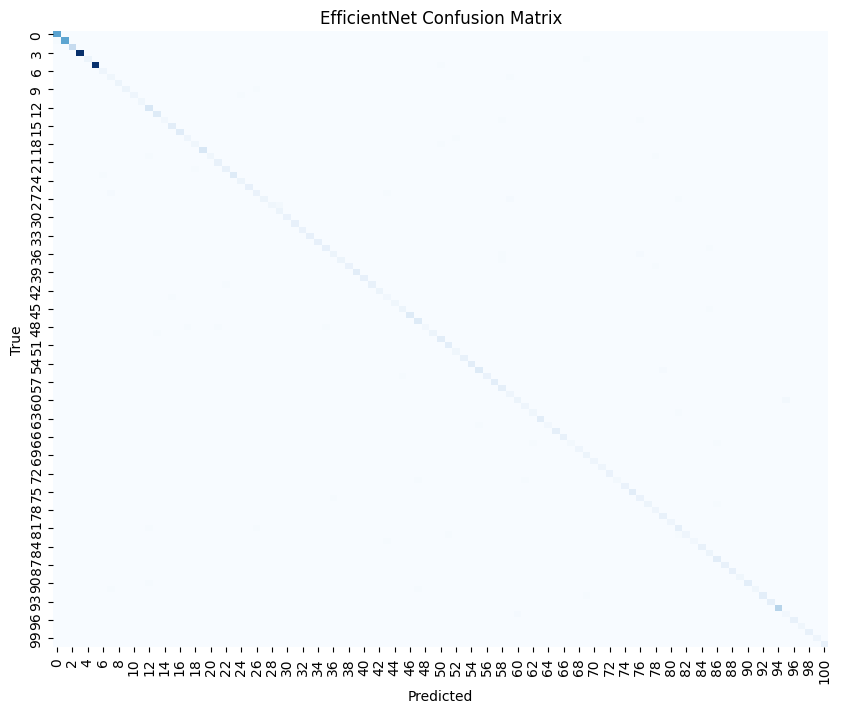

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cm2, cmap="Blues", cbar=False)
plt.title("EfficientNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [39]:
from torchvision import transforms
from torch.utils.data import DataLoader
from PIL import Image

IMG_SIZE_ABL = 64
BATCH_SIZE = 32

train_tfms_64 = transforms.Compose([
    transforms.Resize((IMG_SIZE_ABL, IMG_SIZE_ABL)),
    transforms.RandomHorizontalFlip(p=0.5),  # keep augmentation ON (same as baseline)
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_tfms_64 = transforms.Compose([
    transforms.Resize((IMG_SIZE_ABL, IMG_SIZE_ABL)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_ds_64 = CaltechDataset(train_df, train_tfms_64)
val_ds_64   = CaltechDataset(val_df,   eval_tfms_64)
test_ds_64  = CaltechDataset(test_df,  eval_tfms_64)

train_loader_64 = DataLoader(train_ds_64, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_64   = DataLoader(val_ds_64,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_64  = DataLoader(test_ds_64,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader_64))
print("64px batch:", xb.shape, "| labels:", yb.min().item(), yb.max().item())

64px batch: torch.Size([32, 3, 64, 64]) | labels: 1 94


In [40]:
import torch
import torch.nn as nn
from torchvision import models
from tqdm import tqdm
import copy
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- model (fresh) ---
NUM_CLASSES = len(label2idx)

model_64 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_64.fc = nn.Linear(model_64.fc.in_features, NUM_CLASSES)
model_64 = model_64.to(device)

criterion_64 = nn.CrossEntropyLoss()
optimizer_64 = torch.optim.Adam(model_64.parameters(), lr=1e-4)

def eval_acc(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

# --- training with early stopping ---
EPOCHS_ABL = 8
PATIENCE_ABL = 2

train64_loss_hist, train64_acc_hist, val64_acc_hist = [], [], []

best_val64 = 0.0
best_state64 = copy.deepcopy(model_64.state_dict())
no_improve64 = 0

for epoch in range(1, EPOCHS_ABL + 1):
    model_64.train()
    running_loss = 0.0
    correct, total = 0, 0

    for xb, yb in tqdm(train_loader_64, desc=f"ResNet64 Epoch {epoch}/{EPOCHS_ABL}"):
        xb, yb = xb.to(device), yb.to(device)

        optimizer_64.zero_grad()
        logits = model_64(xb)
        loss = criterion_64(logits, yb)
        loss.backward()
        optimizer_64.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_acc = eval_acc(model_64, val_loader_64)

    train64_loss_hist.append(train_loss)
    train64_acc_hist.append(train_acc)
    val64_acc_hist.append(val_acc)

    print(f"ResNet64 Epoch {epoch}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val64 + 1e-4:
        best_val64 = val_acc
        best_state64 = copy.deepcopy(model_64.state_dict())
        no_improve64 = 0
    else:
        no_improve64 += 1
        if no_improve64 >= PATIENCE_ABL:
            print(f"Early stopping. Best val_acc={best_val64:.4f}")
            break

model_64.load_state_dict(best_state64)
print(f"Loaded best ResNet64 with val_acc={best_val64:.4f}")

# --- test evaluation ---
model_64.eval()
y_true64, y_pred64 = [], []

with torch.no_grad():
    for xb, yb in test_loader_64:
        xb = xb.to(device)
        logits = model_64(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred64.append(preds)
        y_true64.append(yb.numpy())

y_true64 = np.concatenate(y_true64)
y_pred64 = np.concatenate(y_pred64)

test_acc64 = accuracy_score(y_true64, y_pred64)
rep64 = classification_report(y_true64, y_pred64, output_dict=True)

cm64 = confusion_matrix(y_true64, y_pred64)
per_class_acc64 = cm64.diagonal() / cm64.sum(axis=1).clip(min=1)

print("ResNet64 TEST accuracy:", test_acc64)
print("ResNet64 macro F1:", rep64["macro avg"]["f1-score"])
print("ResNet64 weighted F1:", rep64["weighted avg"]["f1-score"])
print("ResNet64 mean per-class accuracy:", per_class_acc64.mean())

ResNet64 Epoch 1/8: 100%|██████████| 190/190 [00:26<00:00,  7.20it/s]


ResNet64 Epoch 1: train_loss=2.3816 train_acc=0.5054 val_acc=0.6959


ResNet64 Epoch 2/8: 100%|██████████| 190/190 [00:26<00:00,  7.28it/s]


ResNet64 Epoch 2: train_loss=0.9201 train_acc=0.7938 val_acc=0.7842


ResNet64 Epoch 3/8: 100%|██████████| 190/190 [00:26<00:00,  7.21it/s]


...

ResNet64 Epoch 5: train_loss=0.1399 train_acc=0.9743 val_acc=0.8395


ResNet64 Epoch 6/8: 100%|██████████| 190/190 [00:26<00:00,  7.25it/s]


ResNet64 Epoch 6: train_loss=0.1016 train_acc=0.9821 val_acc=0.8341


ResNet64 Epoch 7/8: 100%|██████████| 190/190 [00:26<00:00,  7.20it/s]


ResNet64 Epoch 7: train_loss=0.0603 train_acc=0.9919 val_acc=0.8364
Early stopping. Best val_acc=0.8395
Loaded best ResNet64 with val_acc=0.8395
ResNet64 TEST accuracy: 0.8433179723502304
ResNet64 macro F1: 0.7592903901521032
ResNet64 weighted F1: 0.8386075809114346
ResNet64 mean per-class accuracy: 0.7679328627160675


In [41]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

model_64.eval()
y_true64, y_pred64 = [], []

with torch.no_grad():
    for xb, yb in test_loader_64:
        xb = xb.to(device)
        preds = model_64(xb).argmax(dim=1).cpu().numpy()
        y_pred64.append(preds)
        y_true64.append(yb.numpy())

y_true64 = np.concatenate(y_true64)
y_pred64 = np.concatenate(y_pred64)

print("ResNet64 TEST accuracy:", accuracy_score(y_true64, y_pred64))

target_names = [idx2label[i] for i in range(NUM_CLASSES)]
rep64 = classification_report(y_true64, y_pred64, target_names=target_names, digits=4, output_dict=True)

print("ResNet64 macro F1:", rep64["macro avg"]["f1-score"])
print("ResNet64 weighted F1:", rep64["weighted avg"]["f1-score"])

ResNet64 TEST accuracy: 0.8433179723502304
ResNet64 macro F1: 0.7592903901521032
ResNet64 weighted F1: 0.8386075809114346


In [42]:
IMG_SIZE_ABL = 128
BATCH_SIZE = 32

train_tfms_noaug = transforms.Compose([
    transforms.Resize((IMG_SIZE_ABL, IMG_SIZE_ABL)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_tfms_128 = transforms.Compose([
    transforms.Resize((IMG_SIZE_ABL, IMG_SIZE_ABL)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_ds_noaug = CaltechDataset(train_df, train_tfms_noaug)
val_ds_noaug   = CaltechDataset(val_df,   eval_tfms_128)
test_ds_noaug  = CaltechDataset(test_df,  eval_tfms_128)

train_loader_noaug = DataLoader(train_ds_noaug, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_noaug   = DataLoader(val_ds_noaug,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_noaug  = DataLoader(test_ds_noaug,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader_noaug))
print("NoAug batch:", xb.shape)

NoAug batch: torch.Size([32, 3, 128, 128])


In [43]:
from torchvision import models
import torch.nn as nn

model_noaug = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_noaug.fc = nn.Linear(model_noaug.fc.in_features, NUM_CLASSES)
model_noaug = model_noaug.to(device)

criterion_noaug = nn.CrossEntropyLoss()
optimizer_noaug = torch.optim.Adam(model_noaug.parameters(), lr=1e-4)

def eval_acc(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

print("ResNet NoAug model ready.")

ResNet NoAug model ready.


In [44]:
import copy
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

EPOCHS_ABL2 = 8
PATIENCE_ABL2 = 2

best_val_noaug = 0.0
best_state_noaug = copy.deepcopy(model_noaug.state_dict())
no_improve = 0

for epoch in range(1, EPOCHS_ABL2 + 1):
    model_noaug.train()
    running_loss = 0.0
    correct, total = 0, 0

    for xb, yb in tqdm(train_loader_noaug, desc=f"ResNetNoAug Epoch {epoch}/{EPOCHS_ABL2}"):
        xb, yb = xb.to(device), yb.to(device)

        optimizer_noaug.zero_grad()
        logits = model_noaug(xb)
        loss = criterion_noaug(logits, yb)
        loss.backward()
        optimizer_noaug.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_acc = eval_acc(model_noaug, val_loader_noaug)

    print(f"ResNetNoAug Epoch {epoch}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_noaug + 1e-4:
        best_val_noaug = val_acc
        best_state_noaug = copy.deepcopy(model_noaug.state_dict())
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE_ABL2:
            print(f"Early stopping. Best val_acc={best_val_noaug:.4f}")
            break

model_noaug.load_state_dict(best_state_noaug)
print(f"Loaded best ResNetNoAug with val_acc={best_val_noaug:.4f}")

# ---- Test evaluation ----
model_noaug.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for xb, yb in test_loader_noaug:
        xb = xb.to(device)
        preds = model_noaug(xb).argmax(dim=1).cpu().numpy()
        y_pred.append(preds)
        y_true.append(yb.numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

test_acc = accuracy_score(y_true, y_pred)
rep = classification_report(y_true, y_pred, output_dict=True)
cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)

print("ResNetNoAug TEST accuracy:", test_acc)
print("ResNetNoAug macro F1:", rep["macro avg"]["f1-score"])
print("ResNetNoAug weighted F1:", rep["weighted avg"]["f1-score"])
print("ResNetNoAug mean per-class accuracy:", per_class_acc.mean())

ResNetNoAug Epoch 1/8: 100%|██████████| 190/190 [00:27<00:00,  6.80it/s]


ResNetNoAug Epoch 1: train_loss=1.6927 train_acc=0.6694 val_acc=0.8871


ResNetNoAug Epoch 2/8: 100%|██████████| 190/190 [00:28<00:00,  6.66it/s]


ResNetNoAug Epoch 2: train_loss=0.2989 train_acc=0.9572 val_acc=0.9363


ResNetNoAug Epoch 3/8: 100%|██████████| 190/190 [00:27<00:00,  6.80it/s]


...

ResNetNoAug Epoch 6: train_loss=0.0127 train_acc=0.9990 val_acc=0.9455


ResNetNoAug Epoch 7/8: 100%|██████████| 190/190 [00:27<00:00,  6.80it/s]


ResNetNoAug Epoch 7: train_loss=0.0093 train_acc=0.9995 val_acc=0.9478


ResNetNoAug Epoch 8/8: 100%|██████████| 190/190 [00:27<00:00,  6.79it/s]


ResNetNoAug Epoch 8: train_loss=0.0065 train_acc=0.9997 val_acc=0.9432
Loaded best ResNetNoAug with val_acc=0.9478
ResNetNoAug TEST accuracy: 0.9470046082949308
ResNetNoAug macro F1: 0.9188470764201523
ResNetNoAug weighted F1: 0.945625791288017
ResNetNoAug mean per-class accuracy: 0.9165173894571099
